## ML Data Preprocessing Pratik Ghaytidak (25143078)

### Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import Dataset

In [14]:
df = pd.read_csv('Employee.csv');
df.shape
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


### Data Exploration

In [12]:
df.duplicated().sum();
df.drop_duplicates(inplace = True);
df.shape

(144, 6)

In [15]:
df.reset_index(inplace = True)
df.drop('index',axis = 1, inplace = True)
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [17]:
df.head(5)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [19]:
df.isna().sum()

Company     8
Age        18
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [21]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [23]:
unique = df.nunique()
unique

Company     6
Age        29
Salary     40
Place      11
Country     1
Gender      2
dtype: int64

In [24]:
df['Company'].unique()

array(['TCS', 'Infosys', 'CTS', nan, 'Tata Consultancy Services',
       'Congnizant', 'Infosys Pvt Lmt'], dtype=object)

In [28]:
df['Company'] = df['Company'].replace('Tata Consultancy Services','TCS')
df['Company'] = df['Company'].replace('Infosys Pvt Lmt','Infosys')
df['Company'] = df['Company'].replace('CTS','Congnizant')
df['Company'] = df['Company'].replace('Congnizant','Cognizant')
df['Company'].unique()

array(['TCS', 'Infosys', 'Cognizant', nan], dtype=object)

In [31]:
df['Age'].unique()

array([20., 30., 35., 40., 23., nan, 34., 45., 18., 22., 32., 37., 50.,
       21., 46., 36., 26., 41., 24., 25., 43., 19., 38., 51., 31., 44.,
       33., 17.,  0., 54.])

In [32]:
df['Salary'].unique()

array([  nan, 2300., 3000., 4000., 5000., 6000., 7000., 8000., 9000.,
       1089., 1234., 3030., 3045., 3184., 4824., 5835., 7084., 8943.,
       8345., 9284., 9876., 2034., 7654., 2934., 4034., 5034., 8202.,
       9024., 4345., 6544., 6543., 3234., 4324., 5435., 5555., 8787.,
       3454., 5654., 5009., 5098., 3033.])

In [33]:
df['Place'].unique()

array(['Chennai', 'Mumbai', 'Calcutta', 'Delhi', 'Podicherry', 'Cochin',
       nan, 'Noida', 'Hyderabad', 'Bhopal', 'Nagpur', 'Pune'],
      dtype=object)

In [34]:
df['Place'] = df['Place'].replace('Podicherry','Pondicherry')

In [35]:
df['Place'].unique()

array(['Chennai', 'Mumbai', 'Calcutta', 'Delhi', 'Pondicherry', 'Cochin',
       nan, 'Noida', 'Hyderabad', 'Bhopal', 'Nagpur', 'Pune'],
      dtype=object)

In [36]:
df['Country'].unique

<bound method Series.unique of 0      India
1      India
2      India
3      India
4      India
       ...  
143    India
144    India
145    India
146    India
147    India
Name: Country, Length: 148, dtype: object>

In [37]:
df['Gender'].unique

<bound method Series.unique of 0      0
1      0
2      0
3      0
4      0
      ..
143    1
144    1
145    1
146    1
147    0
Name: Gender, Length: 148, dtype: int64>

### Statistical analysis

In [38]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [39]:
df.head(5)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


### Data Cleaning

In [44]:
df1 = pd.read_csv('Employee.csv')
df1.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


##### Age Outlier Detection

In [45]:
q1 = df['Age'].quantile(0.25)
q1

np.float64(22.0)

In [46]:
q3 = df['Age'].quantile(0.75)
q3

np.float64(37.75)

In [47]:
iqr = q3 - q1
iqr

np.float64(15.75)

In [48]:
lower = q1 - 1.5 * iqr
lower

np.float64(-1.625)

In [49]:
upper = q3 + 1.5 * iqr
upper

np.float64(61.375)

In [68]:
df[(df['Age']< lower) | (df['Age']< upper)]

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


##### Salary Outlier Detection

In [59]:
q1 = df['Salary'].quantile(0.25)
q1

np.float64(3030.0)

In [60]:
q3 = df['Salary'].quantile(0.75)
q3

np.float64(8000.0)

In [61]:
iqr = q3 - q1
iqr

np.float64(4970.0)

In [62]:
lower = q1 - 1.5 * iqr
lower

np.float64(-4425.0)

In [63]:
upper = q3 + 1.5 * iqr
upper

np.float64(15455.0)

In [69]:
df[(df['Salary'] < lower) | (df['Salary'] > upper)]

,Company,Age,Salary,Place,Country,Gender


In [70]:
df.isna().sum()

Company     8
Age        18
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [73]:
df['Company'].mode()[0]

'TCS'

In [76]:
df['Company'] = df['Company'].fillna(df['Company'].mode()[0])

In [77]:
df.isna().sum()

Company     0
Age        18
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [90]:
df[df['Age']==0]

,Company,Age,Salary,Place,Country,Gender


In [92]:
 df['Age'] = df['Age'].replace(0,np.nan)

In [93]:
df.isna().sum()

Company     0
Age        24
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [94]:
df.describe()

,Age,Salary,Gender
count,124.000000,124.000000,148.000000
mean,31.959677,5312.467742,0.222973
std,9.034171,2573.764683,0.417654
min,17.000000,1089.000000,0.000000
25%,23.000000,3030.000000,0.000000
50%,33.000000,5000.000000,0.000000
75%,40.000000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [97]:
rounded_mean = round(df['Age'].mean(),0)
rounded_mean

np.float64(32.0)

In [98]:
df['Age'] = df['Age'].fillna(rounded_mean)

In [99]:
df.isna().sum()

Company     0
Age         0
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [101]:
rounded_salary = round(df['Salary'].mean(),0)
rounded_salary

np.float64(5312.0)

In [102]:
df['Salary'] = df['Salary'].fillna(rounded_salary)

In [103]:
df.isna().sum()

Company     0
Age         0
Salary      0
Place      14
Country     0
Gender      0
dtype: int64

In [104]:
df['Place'].mode()

0    Mumbai
Name: Place, dtype: object

In [106]:
df['Place'] = df['Place'].fillna(df['Place'].mode()[0])

In [107]:
df.isna().sum()

Company    0
Age        0
Salary     0
Place      0
Country    0
Gender     0
dtype: int64

In [108]:
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5312.0,Chennai,India,0
1,Infosys,30.0,5312.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


### Data Analysis

In [111]:
df[(df['Age'] > 40) & (df['Salary'] < 5000)]

,Company,Age,Salary,Place,Country,Gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


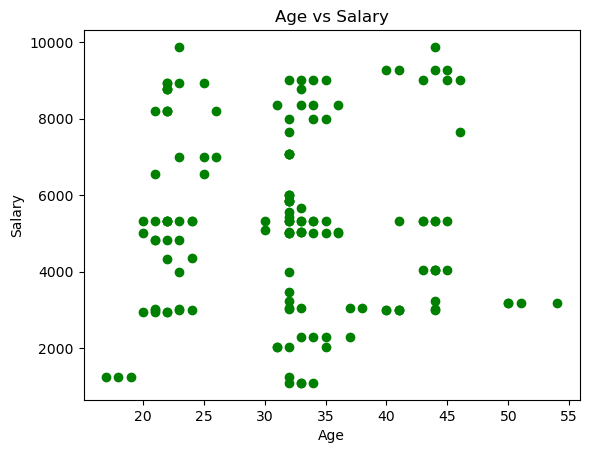

In [114]:
plt.scatter(df['Age'],df['Salary'],color = 'g')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

### Observations from scatter plot

In [115]:
df['Place'].value_counts()

Place
Mumbai         51
Calcutta       33
Chennai        14
Delhi          14
Cochin         13
Noida           8
Hyderabad       8
Pondicherry     3
Pune            2
Bhopal          1
Nagpur          1
Name: count, dtype: int64

In [116]:
x = df['Place'].value_counts().index
x

Index(['Mumbai', 'Calcutta', 'Chennai', 'Delhi', 'Cochin', 'Noida',
       'Hyderabad', 'Pondicherry', 'Pune', 'Bhopal', 'Nagpur'],
      dtype='object', name='Place')

In [117]:
y = df['Place'].value_counts().values
y

array([51, 33, 14, 14, 13,  8,  8,  3,  2,  1,  1])

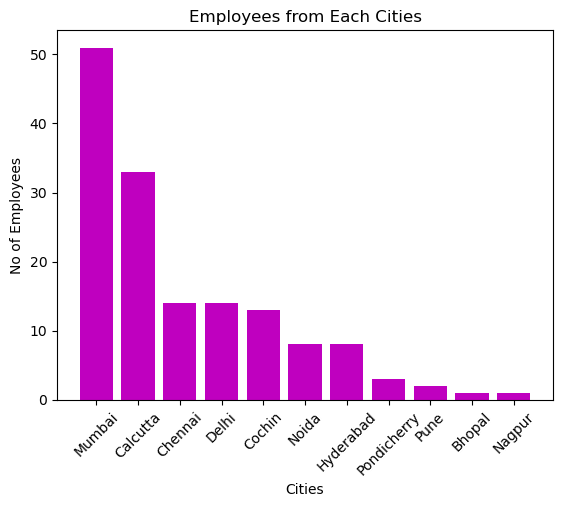

In [119]:
plt.bar(x,y,color = 'm')
plt.xlabel("Cities")
plt.ylabel("No of Employees")
plt.title("Employees from Each Cities")
plt.xticks(rotation = 45)
plt.show()

### Data Encoding

In [120]:
df.head(1)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5312.0,Chennai,India,0


In [121]:
df['Gender'] = df['Gender'].replace(0,'M')

In [122]:
df['Gender'] = df['Gender'].replace(1,'F')

In [123]:
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5312.0,Chennai,India,M
1,Infosys,30.0,5312.0,Mumbai,India,M
2,TCS,35.0,2300.0,Calcutta,India,M
3,Infosys,40.0,3000.0,Delhi,India,M
4,TCS,23.0,4000.0,Mumbai,India,M


In [124]:
df['Gender'].value_counts()

Gender
M    115
F     33
Name: count, dtype: int64

In [125]:
df.describe()

,Age,Salary
count,148.000000,148.000000
mean,31.966216,5312.391892
std,8.263859,2354.305009
min,17.000000,1089.000000
25%,23.000000,3149.250000
50%,32.000000,5312.000000
75%,36.000000,7084.000000
max,54.000000,9876.000000


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  148 non-null    object 
 1   Age      148 non-null    float64
 2   Salary   148 non-null    float64
 3   Place    148 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    object 
dtypes: float64(2), object(4)
memory usage: 7.1+ KB


In [127]:
df.drop('Country',axis = 1, inplace = True)
df

,Company,Age,Salary,Place,Gender
0,TCS,20.0,5312.0,Chennai,M
1,Infosys,30.0,5312.0,Mumbai,M
2,TCS,35.0,2300.0,Calcutta,M
3,Infosys,40.0,3000.0,Delhi,M
4,TCS,23.0,4000.0,Mumbai,M
...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,F
144,Infosys,22.0,8787.0,Calcutta,F
145,Infosys,44.0,4034.0,Delhi,F
146,TCS,33.0,5034.0,Mumbai,F


### OneHotEncoding

In [128]:
df['Company'].unique()

array(['TCS', 'Infosys', 'Cognizant'], dtype=object)

In [129]:
df['Place'].unique()

array(['Chennai', 'Mumbai', 'Calcutta', 'Delhi', 'Pondicherry', 'Cochin',
       'Noida', 'Hyderabad', 'Bhopal', 'Nagpur', 'Pune'], dtype=object)

In [130]:
df['Gender'].unique()

array(['M', 'F'], dtype=object)

In [131]:
 from sklearn.preprocessing import OneHotEncoder

In [132]:
ohe=OneHotEncoder()

In [133]:
ohe

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [134]:
df_array=ohe.fit_transform(df[['Company','Place','Gender']]).toarray()
df_array

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.]], shape=(148, 16))

In [135]:
ohe.categories_

[array(['Cognizant', 'Infosys', 'TCS'], dtype=object),
 array(['Bhopal', 'Calcutta', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad',
        'Mumbai', 'Nagpur', 'Noida', 'Pondicherry', 'Pune'], dtype=object),
 array(['F', 'M'], dtype=object)]

In [136]:
categories=[np.array(['Cognizant','Infosys','TCS']),
            np.array(['Bhopal','Calcutta','Chennai','Cochin','Delhi','Hyderabad','Mumbai','Nagpur','Noida','Pondicherry','Pune']),
            np.array(['F','M'])]

single_list=[innerlistone for main_array in categories for innerlistone in main_array]
single_list

[np.str_('Cognizant'),
 np.str_('Infosys'),
 np.str_('TCS'),
 np.str_('Bhopal'),
 np.str_('Calcutta'),
 np.str_('Chennai'),
 np.str_('Cochin'),
 np.str_('Delhi'),
 np.str_('Hyderabad'),
 np.str_('Mumbai'),
 np.str_('Nagpur'),
 np.str_('Noida'),
 np.str_('Pondicherry'),
 np.str_('Pune'),
 np.str_('F'),
 np.str_('M')]

In [137]:
df_new=pd.DataFrame(df_array,columns=single_list)
df_new

,Cognizant,Infosys,TCS,Bhopal,Calcutta,Chennai,Cochin,Delhi,Hyderabad,Mumbai,Nagpur,Noida,Pondicherry,Pune,F,M
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
146,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [138]:
df_ml=pd.concat([df,df_new],axis=1)
df_ml

,Company,Age,Salary,Place,Gender,Cognizant,Infosys,TCS,Bhopal,Calcutta,...,Cochin,Delhi,Hyderabad,Mumbai,Nagpur,Noida,Pondicherry,Pune,F,M
0,TCS,20.0,5312.0,Chennai,M,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Infosys,30.0,5312.0,Mumbai,M,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,TCS,35.0,2300.0,Calcutta,M,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Infosys,40.0,3000.0,Delhi,M,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,TCS,23.0,4000.0,Mumbai,M,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,F,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144,Infosys,22.0,8787.0,Calcutta,F,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145,Infosys,44.0,4034.0,Delhi,F,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
146,TCS,33.0,5034.0,Mumbai,F,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### LabelEncoder

In [34]:
df.to_csv('Employee_cleaned.csv',index=False)

In [140]:
from sklearn.preprocessing import LabelEncoder

In [141]:
label=LabelEncoder()
print(label)

LabelEncoder()


In [142]:
df_sample=pd.read_csv('Employee_cleaned.csv')
df_sample['Company']=label.fit_transform(df_sample['Company'])

In [143]:
df_sample

,Company,Age,Salary,Place,Gender
0,2,20.0,5312.0,Chennai,M
1,1,30.0,5312.0,Mumbai,M
2,2,35.0,2300.0,Calcutta,M
3,1,40.0,3000.0,Delhi,M
4,2,23.0,4000.0,Mumbai,M
...,...,...,...,...,...
143,2,33.0,9024.0,Calcutta,F
144,1,22.0,8787.0,Calcutta,F
145,1,44.0,4034.0,Delhi,F
146,2,33.0,5034.0,Mumbai,F


### StandardScaler 

In [5]:
df = pd.read_csv('Employee_cleaned.csv')

In [7]:
data = df.iloc[:,[1,2]]
data

,Age,Salary
0,20.0,5312.0
1,30.0,5312.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
143,33.0,9024.0
144,22.0,8787.0
145,44.0,4034.0
146,33.0,5034.0


In [8]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler=StandardScaler().fit(data)
print(scaler)

StandardScaler()


In [13]:
data_scaled = scaler.transform(data)
print(data_scaled)

[[-1.45293481e+00 -1.67022793e-04]
 [-2.38737454e-01 -1.67022793e-04]
 [ 3.68361226e-01 -1.28386965e+00]
 [ 9.75459906e-01 -9.85532389e-01]
 [-1.08867561e+00 -5.59336296e-01]
 [ 4.10201811e-03 -1.33140204e-01]
 [ 4.10201811e-03  2.93055889e-01]
 [-1.08867561e+00  7.19251981e-01]
 [ 2.46941490e-01  1.14544807e+00]
 [ 1.58255859e+00  1.57164417e+00]
 [-1.08867561e+00 -1.67022793e-04]
 [ 2.46941490e-01 -1.79999312e+00]
 [ 1.58255859e+00 -1.67022793e-04]
 [-1.69577429e+00 -1.73819469e+00]
 [ 9.75459906e-01 -9.85532389e-01]
 [-1.08867561e+00 -9.85532389e-01]
 [-1.08867561e+00 -9.72746506e-01]
 [ 2.46941490e-01 -1.33140204e-01]
 [-1.21009534e+00 -1.67022793e-04]
 [ 4.10201811e-03 -1.67022793e-04]
 [ 6.11200698e-01 -9.66353564e-01]
 [ 2.18965727e+00 -9.07112308e-01]
 [-1.33151508e+00 -2.08150716e-01]
 [ 4.10201811e-03  2.22733534e-01]
 [ 4.10201811e-03  7.55052453e-01]
 [-1.08867561e+00  1.54735099e+00]
 [ 2.46941490e-01  1.29248573e+00]
 [ 1.58255859e+00  1.69268386e+00]
 [-1.08867561e+00  1

In [14]:
print(data_scaled.mean(axis=0))

[-1.66533454e-16  1.12522604e-16]


In [15]:
print(data_scaled.std(axis=0))

[1. 1.]


In [16]:
scaled_data_set = pd.DataFrame(data_scaled,columns=data.columns)
scaled_data_set

,Age,Salary
0,-1.452935,-0.000167
1,-0.238737,-0.000167
2,0.368361,-1.283870
3,0.975460,-0.985532
4,-1.088676,-0.559336
...,...,...
143,0.125522,1.581873
144,-1.210095,1.480864
145,1.461139,-0.544846
146,0.125522,-0.118650


In [33]:
scaled_data_set.to_csv("scaled_data_set.csv")

### MinMaxScaler

In [17]:
data = df.iloc[:,[1,2]]
data

,Age,Salary
0,20.0,5312.0
1,30.0,5312.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
143,33.0,9024.0
144,22.0,8787.0
145,44.0,4034.0
146,33.0,5034.0


In [20]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
scaler = MinMaxScaler().fit(data)
print(scaler)

MinMaxScaler()


In [23]:
scaler.data_min_

array([  17., 1089.])

In [24]:
scaler.data_max_

array([  54., 9876.])

In [25]:
data.describe

<bound method NDFrame.describe of       Age  Salary
0    20.0  5312.0
1    30.0  5312.0
2    35.0  2300.0
3    40.0  3000.0
4    23.0  4000.0
..    ...     ...
143  33.0  9024.0
144  22.0  8787.0
145  44.0  4034.0
146  33.0  5034.0
147  22.0  8202.0

[148 rows x 2 columns]>

In [26]:
scaler.feature_range

(0, 1)

In [27]:
data_scaled_mm = scaler.transform(data)
print(data_scaled_mm)

[[0.08108108 0.48059634]
 [0.35135135 0.48059634]
 [0.48648649 0.13781723]
 [0.62162162 0.21748037]
 [0.16216216 0.33128485]
 [0.40540541 0.44508934]
 [0.40540541 0.55889382]
 [0.16216216 0.6726983 ]
 [0.45945946 0.78650279]
 [0.75675676 0.90030727]
 [0.16216216 0.48059634]
 [0.45945946 0.        ]
 [0.75675676 0.48059634]
 [0.02702703 0.01650165]
 [0.62162162 0.21748037]
 [0.16216216 0.21748037]
 [0.16216216 0.2208945 ]
 [0.45945946 0.44508934]
 [0.13513514 0.48059634]
 [0.40540541 0.48059634]
 [0.54054054 0.22260157]
 [0.89189189 0.23842039]
 [0.10810811 0.42505975]
 [0.40540541 0.54011608]
 [0.40540541 0.68225788]
 [0.16216216 0.89382042]
 [0.45945946 0.82576534]
 [0.75675676 0.93262775]
 [0.16216216 1.        ]
 [0.48648649 0.10754524]
 [0.78378378 0.74712644]
 [0.08108108 0.20996927]
 [0.75675676 0.33515421]
 [0.51351351 0.44895869]
 [0.24324324 0.80949129]
 [0.48648649 0.90303858]
 [0.40540541 0.48059634]
 [0.48648649 0.48059634]
 [0.45945946 0.13781723]
 [0.64864865 0.21748037]


In [28]:
mm_scaled_data_set = pd.DataFrame(data_scaled_mm,columns=data.columns)
mm_scaled_data_set

,Age,Salary
0,0.081081,0.480596
1,0.351351,0.480596
2,0.486486,0.137817
3,0.621622,0.217480
4,0.162162,0.331285
...,...,...
143,0.432432,0.903039
144,0.135135,0.876067
145,0.729730,0.335154
146,0.432432,0.448959


In [32]:
mm_scaled_data_set.to_csv("mm_scaled_data_set.csv")